### Golf Weather-to-Revenue Model ###

**Quantifying how weather affects rounds played and revenue at a Scottish links
golf course, and translating the results into commercial recommendations.**

**Data transparency:** Weather data is real (Open-Meteo historical archive,
St Andrews). Booking data is **simulated** — calibrated using my experience
working in golf operations. All prices and capacities are illustrative.
The methodology mirrors a private analysis I ran on ~6 months of real daily
operations data that I collected myself; that data is not published.

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

**1. Weather Data**

In [2]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 56.34,
    "longitude": -2.79,
    "start_date": "2023-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,precipitation_sum,wind_speed_10m_max,sunshine_duration",
    "timezone": "Europe/London",
}
r = requests.get(url, params=params, timeout=60)
weather = pd.DataFrame(r.json()["daily"])
weather["time"] = pd.to_datetime(weather["time"])
weather["sunshine_hours"] = weather["sunshine_duration"] / 3600
weather = weather.drop(columns=["sunshine_duration"])
weather.to_csv("../data/weather.csv", index=False)
weather.head()

,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,sunshine_hours
0,2023-01-01,5.3,8.9,26.4,2.030117
1,2023-01-02,2.9,0.0,18.2,6.363992
2,2023-01-03,7.7,9.8,28.0,0.577408
3,2023-01-04,11.0,5.3,38.5,1.784658
4,2023-01-05,10.0,5.1,31.1,0.000000


**2. Simulated Bookings**

In [3]:
rng = np.random.default_rng(42)
df = pd.read_csv("../data/weather.csv", parse_dates=["time"])

# --- illustrative assumptions ---
BASE_ROUNDS = 120
SEASONAL_AMPLITUDE = 80
WEEKEND_UPLIFT = 15
RAIN_PENALTY = -3.5
WIND_THRESHOLD = 20
WIND_PENALTY = -1.2
TEMP_EFFECT = 1.5
# --------------------------------

day_of_year = df["time"].dt.dayofyear
seasonal = BASE_ROUNDS + SEASONAL_AMPLITUDE * np.sin((day_of_year - 105) / 365 * 2 * np.pi)
weekend = df["time"].dt.dayofweek.isin([4, 5]).astype(int) * WEEKEND_UPLIFT
rain = RAIN_PENALTY * df["precipitation_sum"]
wind = WIND_PENALTY * (df["wind_speed_10m_max"] - WIND_THRESHOLD).clip(lower=0)
temp = TEMP_EFFECT * (df["temperature_2m_max"] - 10)
noise = rng.normal(0, 12, len(df))

df["rounds"] = (seasonal + weekend + rain + wind + temp + noise).clip(lower=0).round()

green_fee = np.where(df["time"].dt.month.isin([5, 6, 7, 8, 9]), 150, 90)
ancillary = rng.normal(22, 5, len(df))
df["revenue"] = (df["rounds"] * green_fee + df["rounds"] * ancillary).round(2)

df.to_csv("../data/bookings.csv", index=False)
df[["rounds", "revenue"]].describe()

,rounds,revenue
count,1096.000000,1096.000000
mean,112.839416,17137.467062
std,68.178799,12732.164352
min,0.000000,0.000000
25%,51.000000,5715.955000
50%,112.000000,12858.810000
75%,178.000000,30376.167500
max,245.000000,45640.360000


**3. Exploration**

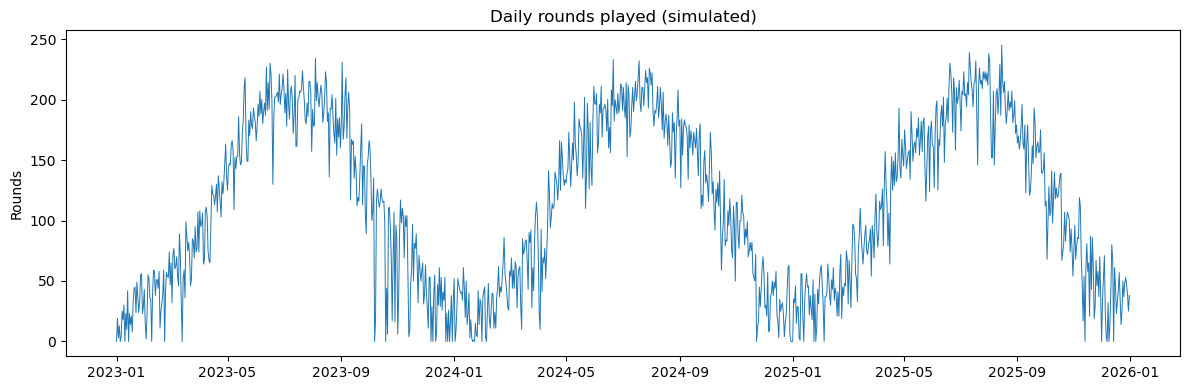

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["time"], df["rounds"], lw=0.7)
ax.set_title("Daily rounds played (simulated)")
ax.set_ylabel("Rounds")
plt.tight_layout()
plt.savefig("../figures/timeseries.png", dpi=150, bbox_inches="tight")

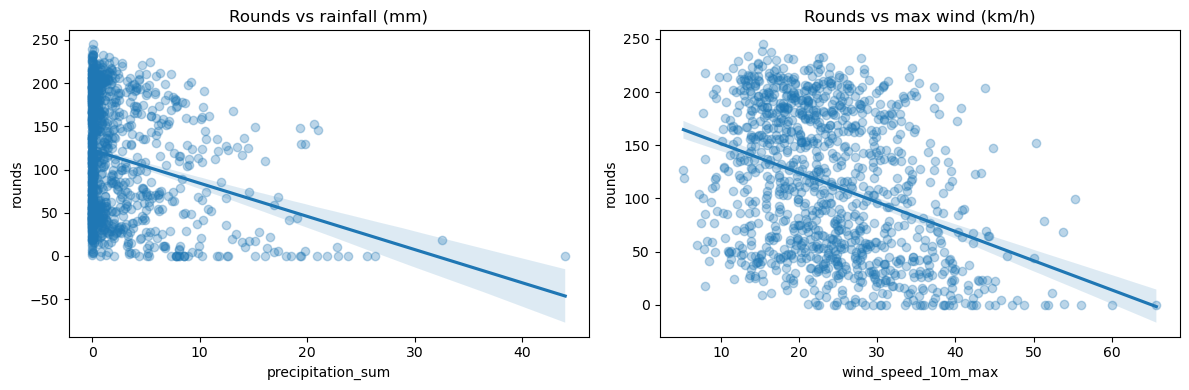

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=df, x="precipitation_sum", y="rounds", ax=ax[0], scatter_kws={"alpha": 0.3})
sns.regplot(data=df, x="wind_speed_10m_max", y="rounds", ax=ax[1], scatter_kws={"alpha": 0.3})
ax[0].set_title("Rounds vs rainfall (mm)")
ax[1].set_title("Rounds vs max wind (km/h)")
plt.tight_layout()
plt.savefig("../figures/scatters.png", dpi=150, bbox_inches="tight")

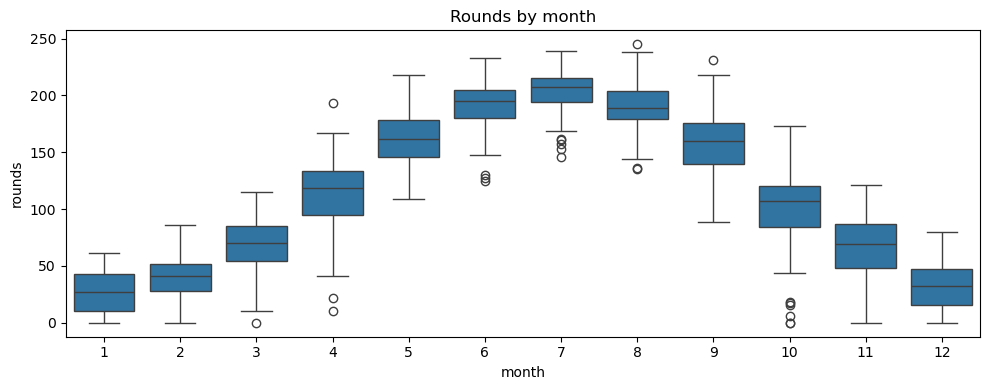

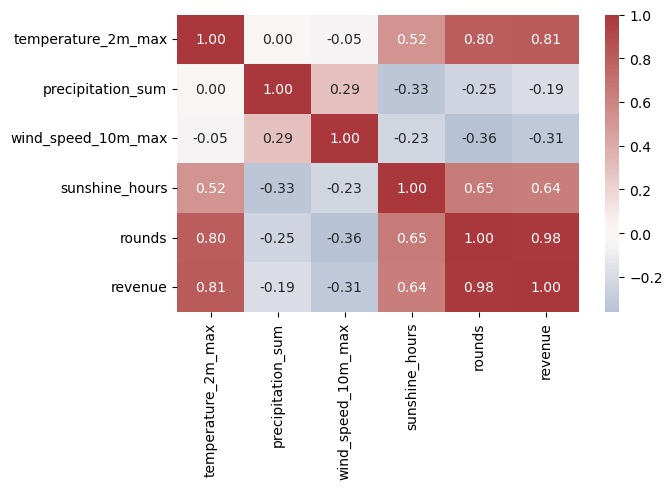

In [14]:
df["month"] = df["time"].dt.month

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="month", y="rounds", ax=ax)
ax.set_title("Rounds by month")
plt.tight_layout()
plt.savefig("../figures/monthly.png", dpi=150, bbox_inches="tight")

cols = ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max",
        "sunshine_hours", "rounds", "revenue"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.tight_layout()
plt.savefig("../figures/heatmap.png", dpi=150, bbox_inches="tight")

The raw scatter plots overstate weather effects: wet and windy days cluster in
winter, when demand is low for seasonal reasons. The regression below separates
weather effects from seasonality.

**4. Regression Model**

In [7]:
df["is_weekend"] = df["time"].dt.dayofweek.isin([4, 5]).astype(int)

model = smf.ols(
    "rounds ~ precipitation_sum + wind_speed_10m_max + temperature_2m_max "
    "+ sunshine_hours + is_weekend + C(month)",
    data=df,
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rounds   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1332.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:10:27   Log-Likelihood:                -4520.3
No. Observations:                1096   AIC:                             9075.
Df Residuals:                    1079   BIC:                             9160.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             38.4412      2

In [8]:
df["wind_excess"] = (df["wind_speed_10m_max"] - 35).clip(lower=0)

model2 = smf.ols(
    "rounds ~ precipitation_sum + wind_excess + temperature_2m_max "
    "+ sunshine_hours + is_weekend + C(month)",
    data=df,
).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 rounds   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     1080.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:10:27   Log-Likelihood:                -4629.0
No. Observations:                1096   AIC:                             9292.
Df Residuals:                    1079   BIC:                             9377.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             16.9181      2

**Note on real-data validation:**
The same specification run privately on ~6 months of real operations data found:
rainfall −1.9 rounds per mm (p < 0.05), sunshine +2.5 rounds/hour, weekend +10
rounds — and **no independent wind effect**, in either linear or threshold form,
once seasonality was controlled. The wind result contradicts both conventional
wisdom and the assumption in this simulation.

**5. Revenue Impact**

In [9]:
rain_coef = abs(model.params["precipitation_sum"])
df["rain_lost_rounds"] = rain_coef * df["precipitation_sum"]

rev_per_round = 100      # illustrative blended revenue per round
recovery_rate = 0.25     # share of lost rounds recoverable via standby pricing
standby_discount = 0.6   # standby price as share of full price

annual = df[df["time"].dt.year == 2024]
lost = annual["rain_lost_rounds"].sum()

print(f"Estimated rounds lost to rain (2024): {lost:.0f}")
print(f"Estimated revenue at risk: £{lost * rev_per_round:,.0f}")
print(f"Recoverable via rain-triggered standby pricing: £{lost * recovery_rate * rev_per_round * standby_discount:,.0f}")

Estimated rounds lost to rain (2024): 2494
Estimated revenue at risk: £249,434
Recoverable via rain-triggered standby pricing: £37,415


In [10]:
rows = []
for rec in [0.10, 0.25, 0.40]:
    for disc in [0.5, 0.6, 0.7]:
        rows.append({"recovery_rate": rec, "standby_price_pct": disc,
                     "annual_recovery_£": round(lost * rec * rev_per_round * disc)})
pd.DataFrame(rows).pivot(index="recovery_rate", columns="standby_price_pct",
                         values="annual_recovery_£")

standby_price_pct,0.5,0.6,0.7
recovery_rate,,,
0.10,12472,14966,17460
0.25,31179,37415,43651
0.40,49887,59864,69842
